# Workplace Gender Equality in Australia
**Mini Project 1 — Matthew Krupa**

---

## 1. Setup & Data Loading

### 1.1 Import Libraries

In [1]:
# --- Import libraries ---
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
from scipy.stats import chisquare

### 1.2 Load WGEA Workforce Data

In [2]:
# --- Import WGEA data ---
cols = ('employer_size', 'anzsic_code',
       'anzsic_division', 'anzsic_subdivision', 'anzsic_group', 'anzsic_class',
       'movement_type', 'manager_category', 'manager_type',
       'employment_status', 'employment_type', 'gender', 'n_employees')
df = pd.read_csv('Data/wgea_public_dataset_2024/wgea_workforce_management_statistics_2024.csv',usecols=cols)

df2 = pd.read_csv('Data/wgea_public_dataset_2024/wgea_workforce_composition_2024.csv')
df2['employment_type'] = df2['employment_type'].str.title()
df2['is_relevant_employer'] = df2['is_relevant_employer'] != 'False'

PT = df2[df2['employment_status'] == 'Part-time'] # part-time employees
FT = df2[df2['employment_status'] == 'Full-time'] # full-time employees


In [3]:
df2.sample(5)

,reporting_year,corporate_group_name,employer_name,employer_abn,is_relevant_employer,employer_size,anzsic_code,anzsic_division,anzsic_subdivision,anzsic_group,anzsic_class,manager_category,occupation,employment_status,employment_type,gender,n_employees
55332,2023-24,Elmo Software Limited,Elmo Software Limited,1.310246e+10,True,250-499,8101.0,Education and Training,Tertiary Education,Tertiary Education,Technical and Vocational Education and Training,Manager,Senior managers,Full-time,Permanent,Women,2
141161,2023-24,Salmon Earthmoving Holdings Pty Ltd,Salmon Earthmoving Holdings Pty Ltd,2.062901e+10,True,250-499,6631.0,"Rental, Hiring and Real Estate Services",Rental and Hiring Services (except Real Estate),Other Goods and Equipment Rental and Hiring,Heavy Machinery and Scaffolding Rental and Hiring,Non-manager,Labourers,Casual,Casual,Men,24
18985,2023-24,Awp Australia Pty Ltd,Awp Australia Pty Ltd,5.209723e+10,True,250-499,6322.0,Financial and Insurance Services,Insurance and Superannuation Funds,Health and General Insurance,General Insurance,Non-manager,Professionals,Part-time,Permanent,Women,50
159414,2023-24,"Tesla Motors Australia, Pty Ltd","Tesla Motors Australia, Pty Ltd",6.814289e+10,True,500-999,3911.0,Retail Trade,Motor Vehicle and Motor Vehicle Parts Retailing,Motor Vehicle Retailing,Car Retailing,Manager,CEOs,Full-time,Permanent,Men,1
40943,2023-24,Cochlear Limited,Cochlear Limited,9.600262e+10,True,1000-4999,2412.0,Manufacturing,Machinery and Equipment Manufacturing,Professional and Scientific Equipment Manufact...,Medical and Surgical Equipment Manufacturing,Non-manager,Professionals,Casual,Casual,Men,3


In [4]:
FT.sample(5)

,reporting_year,corporate_group_name,employer_name,employer_abn,is_relevant_employer,employer_size,anzsic_code,anzsic_division,anzsic_subdivision,anzsic_group,anzsic_class,manager_category,occupation,employment_status,employment_type,gender,n_employees
87266,2023-24,Kempe Services Pty Ltd,Kempe Services Pty Ltd,6.108980e+10,True,<250,7212.0,Administrative and Support Services,Administrative Services,Employment Services,Labour Supply Services,Non-manager,Clerical and Administrative Workers,Full-time,Permanent,Men,3
90037,2023-24,LOYALTY PACIFIC PTY LTD,LOYALTY PACIFIC PTY LTD,8.205793e+10,True,250-499,6940.0,"Professional, Scientific and Technical Services","Professional, Scientific and Technical Service...",Advertising Services,Advertising Services,Non-manager,Professionals,Full-time,Permanent,Men,113
112618,2023-24,National Rugby League Limited,National Rugby League Limited,2.308209e+10,True,500-999,9114.0,Arts and Recreation Services,Sports and Recreation Activities,Sports and Physical Recreation Activities,Sports and Physical Recreation Administrative ...,Non-manager,Clerical and Administrative Workers,Full-time,Contract,Men,3
84286,2023-24,Jasco Holdings Limited,Subsidiaries of Jasco Holdings Limited,NaN,True,<250,NaN,NaN,NaN,NaN,NaN,Manager,Key Management Personnel,Full-time,Permanent,Men,2
156437,2023-24,THE TRUSTEE FOR ARTHUR TZANEROS DISCRETIONARY ...,RRC AUSTRALIA PTY LTD,2.962440e+10,True,<250,7212.0,Administrative and Support Services,Administrative Services,Employment Services,Labour Supply Services,Manager,Key Management Personnel,Full-time,Permanent,Men,1


### 1.3 Load Wage Data

In [8]:
# --- Import wage data ---

# historical wages data: ignore paid leave categories and only include full time
histwage = pd.read_csv('Data/wgea_public_dataset_2024/historical_wages.csv')
histwage = histwage[histwage['Whether had paid leave entitlements'] == 'Total']
histwage['date'] = pd.to_datetime(histwage['Survey month'])
histwage['year'] = histwage['date'].dt.year
histwage = histwage[histwage['Full-time or part-time status'] == 'Full-time']

# FY24 wages by industry data: 
FY24 = pd.read_csv('FY24.csv')

filters = (
    (FY24["Category"] == "Full-time")
    & (FY24["Classification"] == "Mean earnings")
    & (FY24["Leave entitlements"] == "Total employees")
)

FY24_FT = FY24.loc[filters]

#FY24_FTa
earnings = (
    FY24_FT.iloc[:, [4, 10, 13]]
    .rename(columns={FY24_FT.columns[4]: "Industry",
                     FY24_FT.columns[10]: "Male",
                     FY24_FT.columns[13]: "Female"})
    .query("Industry != 'Total'")
)

# FY24_FTb
earnings_c = (
    FY24_FT.iloc[:, [4, 10, 12, 13, 15]]
    .rename(columns={FY24_FT.columns[4]: "Industry",
                     FY24_FT.columns[10]: "Male",
                     FY24_FT.columns[12]: "M_count",
                     FY24_FT.columns[13]: "Female",
                     FY24_FT.columns[15]: "F_count"})
    .query("Industry != 'Total'")
)

In [9]:
earnings.head()

,Industry,Male,Female
212,Accommodation and food services,1510.276,1598.796
349,Administrative and support services,1866.146,1806.803
485,"Agriculture, forestry and fishing",1596.691,1327.213
617,Arts and recreation services,2051.478,1771.814
756,Construction,1860.279,1902.220


---

## 2. Introduction

The Workplace Gender Equality Agency (WGEA) is an Australian Government statutory agency created by the Workplace Gender Equality Act 2012. The agency's purpose is to collect workforce data from employers and work with them to improve gender inequality.

The data collected by the WGEA is based on 2023-2024 private sector employer reports from employers with 100 or more employees.

The national gender pay gap according to the Australian Bureau of Statistics is 11.5%.

As of May 2025, the full-time adult average weekly ordinary time earnings across all industries and occupations was \\$2106.40 for men and \\$1864.10 for women.

### 2.1 Defining the Gender Pay Gap

The gender pay gap (GPG) is calculated as the difference between the average earnings for men and women, expressed as a percentage of men's average earnings:

$$
\frac{(MAV - FAV)}{MAV} \times 100
$$

The lower the number the greater the parity. As can be seen in the below chart, pay equality has fallen sharply over the past 10 years.

---

## 3. Historical Pay Gap Trends

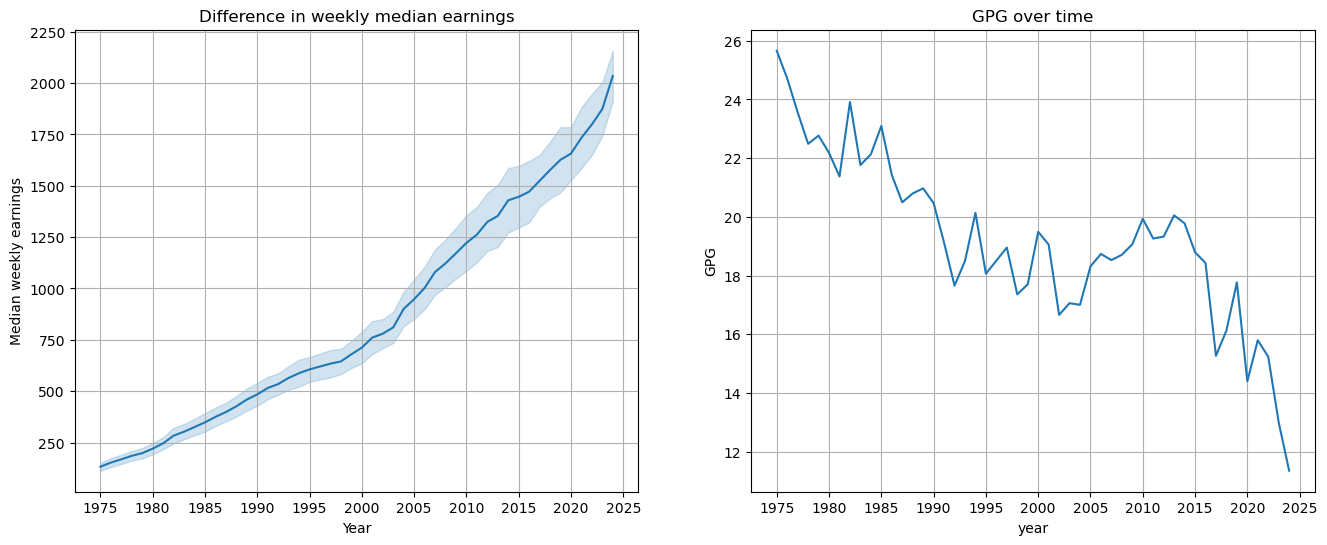

In [11]:
# --- Plot difference in earnings ---
plt.figure(figsize=(16, 6))
years_t = [1975,1980,1985,1990,1995,2000,2005,2010,2015,2020,2025]
years_l = ['1975','1980','1985','1990','1995','2000','2005','2010','2015','2020','2025']

histwage = histwage[histwage['Parameter'] == 'Mean weekly earnings']
fulltime = histwage.groupby(['year','Sex'])['wages'].sum().reset_index()
# fulltime['wages_norm'] = (fulltime['wages'] - fulltime['wages'].min()) / (fulltime['wages'].max() - fulltime['wages'].min())

# --- Difference in weekly median earnings ---
plt.subplot(1,2,1)
sns.lineplot(fulltime,x='year',y='wages')
plt.xlabel('Year')
plt.ylabel('Median weekly earnings')
plt.title('Difference in weekly median earnings')
plt.grid()
plt.xticks(years_t,years_l)
# plt.savefig('difference.png')

# --- Gender pay gap ---
plt.subplot(1,2,2)
fulltime = pd.crosstab(histwage['year'],histwage['Sex'],values=histwage['wages'],aggfunc='sum').reset_index()
fulltime['GPG'] = ((fulltime['   Males'] - fulltime['   Females']) / fulltime['   Males'])*100
sns.lineplot(fulltime,x='year',y='GPG')
plt.title('GPG over time')
plt.grid()
plt.xticks(years_t,years_l)
# plt.savefig('hist_gap.png')

plt.show()

---

## 4. Gender Split of the Workforce

This report covers 5,155,750 employees, with 2,515,212 men and 2,640,538 women.

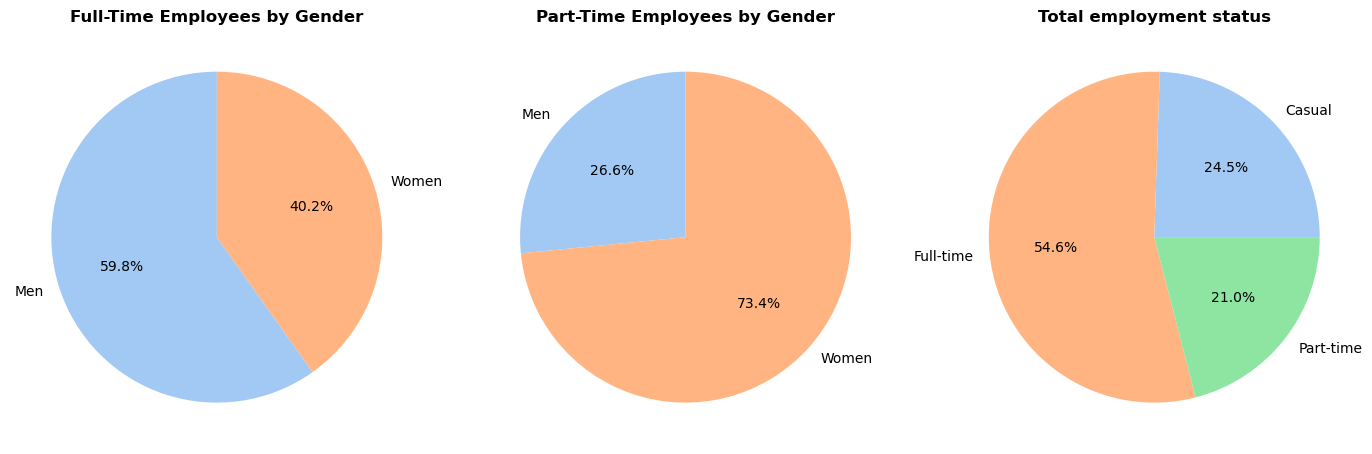

,employment_status,gender,n_employees
0,Casual,Men,545296
1,Casual,Women,716070
2,Full-time,Men,1682587
3,Full-time,Women,1130080
4,Part-time,Men,287329
5,Part-time,Women,794388


In [12]:
# -- Plot workforce distributions ---

# 1. Gender Distribution

plt.figure(figsize=(14, 5))

# colors = ['lightcyan','powderblue','paleturquoise']
sns.set_palette('pastel')

# 1a. Full-time Gender Distribution
plt.subplot(1, 3, 1)
t = FT.groupby(['gender'])['n_employees'].sum()
plt.pie(t.values, labels=t.index, autopct='%1.1f%%', startangle=90)
plt.title('Full-Time Employees by Gender',fontweight='bold')
# plt.savefig('pie_gend.png')

# 1a. Part-time Gender Distribution
plt.subplot(1, 3, 2)
t = PT.groupby(['gender'])['n_employees'].sum()
plt.pie(t.values, labels=t.index, autopct='%1.1f%%', startangle=90)
plt.title('Part-Time Employees by Gender',fontweight='bold')
# plt.savefig('pie_gend2.png')

# 1a. Part-time Gender Distribution
plt.subplot(1, 3, 3)
t = df2.groupby(['employment_status'])['n_employees'].sum()
plt.pie(t.values, labels=t.index, autopct='%1.1f%%')
plt.title('Total employment status',fontweight='bold')
# plt.savefig('pie_gend3.png')

# # 1b. Management Gender Distribution
# plt.subplot(1, 3, 2)
# ceo = FT[FT['occupation'].isin(['CEOs'])]
# execs = FT[FT['occupation'].isin(['Other Executives and General Managers'])]
# ceo = ceo.groupby(['gender'])['n_employees'].sum()
# plt.pie(ceo.values,labels=ceo.index,autopct='%1.1f%%', startangle=90, colors=colors)
# plt.title('CEO by gender',fontweight='bold')

plt.tight_layout()
plt.show()

table = df2.groupby(['employment_status','gender'])['n_employees'].sum().reset_index()
table

---

## 5. Gender Distribution by Industry

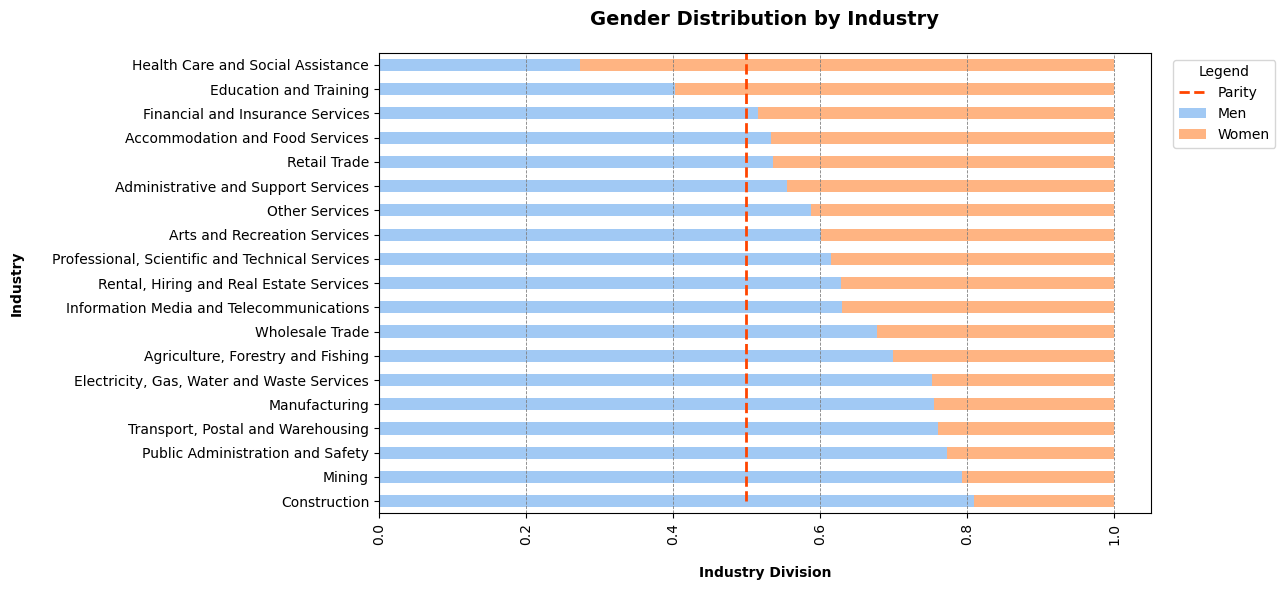

In [13]:
# --- Gender distribution by industry ---
industry_ct = pd.crosstab(
    FT['anzsic_division'],
    FT['gender'],
    values=FT['n_employees'],
    aggfunc='sum'
).fillna(0)

industry_ct_norm = industry_ct.div(industry_ct.sum(axis=1), axis=0).sort_values(by='Men',ascending=False)
industry_ct_norm.plot(kind="barh", stacked=True, figsize=(13,6))
plt.title("Gender Distribution by Industry",fontweight='bold',pad=20,fontsize=14)
plt.ylabel("Industry",labelpad=20,fontweight='bold')
plt.xlabel("Industry Division",labelpad=15,fontweight='bold')
plt.xticks(rotation=90)

plt.grid(color='grey', linestyle='--', linewidth=0.6, axis='x')
plt.vlines(x=0.5, ymin=0, ymax=19, colors='orangered', linestyles='dashed', label='Parity',linewidth=2)
plt.legend(title="Legend", bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.savefig('gen_dis_ind.png')
plt.show()

In [14]:
from sklearn.preprocessing import StandardScaler
industry_ct_rt = industry_ct
industry_ct_rt['ratio'] = industry_ct_rt['Men']/industry_ct_rt['Women']
industry_ct_rt['std'] = (industry_ct_rt['ratio'] - industry_ct_rt['ratio'].mean()) / industry_ct_rt['ratio'].std()

In [15]:
industry_ct_rt

gender,Men,Women,ratio,std
anzsic_division,,,,
Accommodation and Food Services,34189,29919,1.142719,-0.807688
Administrative and Support Services,66546,53368,1.246927,-0.714106
"Agriculture, Forestry and Fishing",14649,6281,2.332272,0.260567
Arts and Recreation Services,20030,13273,1.509079,-0.478686
Construction,110253,26043,4.233498,1.967928
Education and Training,98169,145546,0.674488,-1.228174
"Electricity, Gas, Water and Waste Services",40779,13449,3.032121,0.889054
Financial and Insurance Services,143340,134446,1.066153,-0.876447
Health Care and Social Assistance,68537,182336,0.375883,-1.496331


---

## 6. Gender Pay Gap by Industry

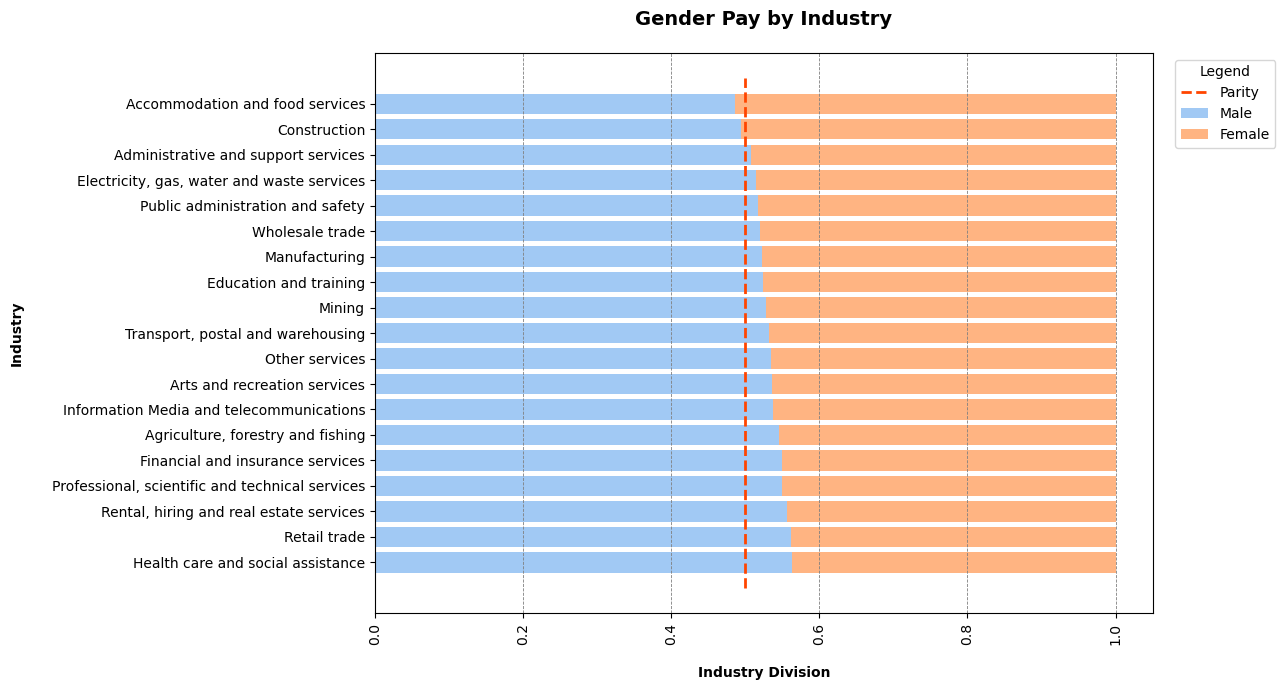

In [16]:
# --- Gender Pay by industry ---
earnings_melt = earnings.melt(id_vars='Industry')
earnings_ct = pd.crosstab(
    earnings_melt['Industry'],
    earnings_melt['variable'],
    values=earnings_melt['value'],
    aggfunc='sum'
).fillna(0)

cool = sns.set_palette('pastel')

plt.figure(figsize=(13, 7))

earnings_norm = earnings_ct.div(earnings_ct.sum(axis=1), axis=0).sort_values(by='Male',ascending=False).reset_index()

categories = earnings_norm['Industry']
segment1_values = earnings_norm['Male']
segment2_values = earnings_norm['Female']

plt.barh(categories, segment1_values, label='Male',)  # First segment
plt.barh(categories, segment2_values, left=segment1_values,  label='Female')

plt.title("Gender Pay by Industry",fontweight='bold',pad=20,fontsize=14)
plt.ylabel("Industry",labelpad=20,fontweight='bold')
plt.xlabel("Industry Division",labelpad=15,fontweight='bold')
plt.xticks(rotation=90)

plt.grid(color='grey', linestyle='--', linewidth=0.6, axis='x')
plt.vlines(x=0.5, ymin=-1, ymax=19, colors='orangered', linestyles='dashed', label='Parity',linewidth=2)
plt.legend(title="Legend", bbox_to_anchor=(1.02, 1), loc='upper left')
# plt.savefig('gen_pay_ind.png')
plt.tight_layout()
plt.show()


In [17]:
# --- Pivot to have Industry x (gender as columns, wage as separate dimension)

FT_long = earnings.melt(id_vars=["Industry"], var_name="gender", value_name="Pay")

# Separate by gender for comparisons
men = FT_long[FT_long["gender"] == "Male"]
women = FT_long[FT_long["gender"] == "Female"]

gender_results = []

for industry in FT_long["Industry"].unique():
    men_vals = men[men["Industry"] == industry]["Pay"].dropna()
    women_vals = women[women["Industry"] == industry]["Pay"].dropna()
    
    # Ensure equal lengths by aligning skill levels
    merged = pd.merge(
        men[men["Industry"] == industry],
        women[women["Industry"] == industry],
        on="Industry",
        suffixes=("_men", "_women")
    )
    
    if len(merged) > 0:
        gender_results.append({
            "Industry": industry,
            "Mean_Men": merged["Pay_men"].mean() if "Pay_men" in merged.columns else None,
            "Mean_Women": merged["Pay_women"].mean() if "Pay_women" in merged.columns else None,
            "Gap": (merged["Pay_men"].mean() - merged["Pay_women"].mean()) if ("Pay_men" in merged.columns and "Pay_women" in merged.columns) else None
        })

gender_results_FT = pd.DataFrame(gender_results)

In [18]:
gender_results_FT

,Industry,Mean_Men,Mean_Women,Gap
0,Accommodation and food services,1510.276,1598.796,-88.520
1,Administrative and support services,1866.146,1806.803,59.343
2,"Agriculture, forestry and fishing",1596.691,1327.213,269.478
3,Arts and recreation services,2051.478,1771.814,279.664
4,Construction,1860.279,1902.220,-41.941
5,Education and training,2304.725,2093.381,211.344
6,"Electricity, gas, water and waste services",2402.807,2270.761,132.046
7,Financial and insurance services,2530.894,2074.209,456.685
8,Health care and social assistance,2323.444,1798.167,525.277
9,Information Media and telecommunications,2466.227,2125.492,340.735


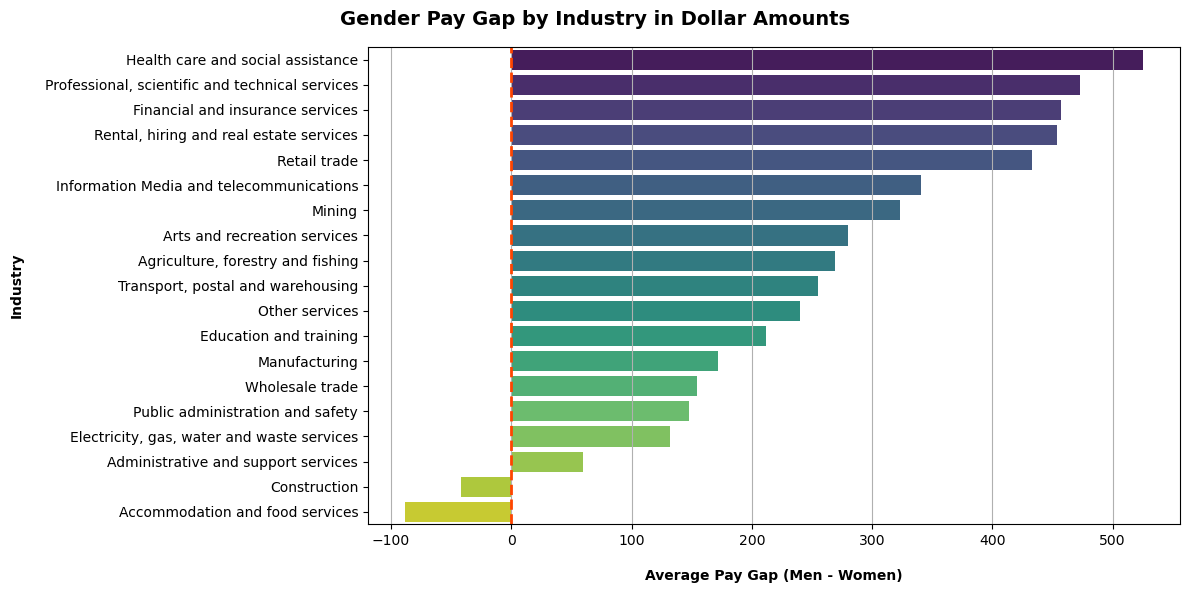

In [19]:
# --- Barplot of Gender Gaps by Industry ---
plt.figure(figsize=(12,6))
sns.color_palette("viridis", as_cmap=True)
sns.barplot(data=gender_results_FT.sort_values("Gap", ascending=False),
            x="Gap", y="Industry", hue='Industry',palette="viridis")
plt.axvline(0, color="orangered", linestyle="--",linewidth=2)
plt.suptitle("Gender Pay Gap by Industry in Dollar Amounts", fontweight='bold',fontsize=14)
plt.xlabel("Average Pay Gap (Men - Women)",labelpad=15,fontweight='bold')
plt.ylabel("Industry",labelpad=15,fontweight='bold')

plt.tight_layout()
plt.grid(axis='x')
plt.show()

---

## 7. Skill Level Analysis

Skill level is defined by the ABS as:
- **Level 1:** Bachelor degree or higher qualification
- **Level 2:** Associate Degree, Advanced Diploma or Diploma
- **Level 3:** AQF Certificate IV or AQF Certificate III including at least two years of on-the-job training
- **Level 4:** Certificate II or III
- **Level 5:** Certificate I or compulsory secondary education

In [20]:
# --- Skill Level ---
skill = FY24[FY24['Classification'].isin(['Skill level of main job'])]
skill = skill[skill['Leave entitlements'] == 'Total employees']
skill_c = skill.iloc[:,[4,6,10,12,13,15]]
skill = skill.iloc[:,[4,6,10,13]]
skill.columns = ['Industry','Skill','Male','Female']
skill_c.columns = ['Industry','Skill','Male','Male_c','Female','Female_c']

In [21]:
# --- Reshape Data ---
# Pivot to have Industry x (Skill levels as columns, Gender as separate dimension)

df_long = skill.melt(id_vars=['Industry','Skill'],var_name="gender", value_name="Pay")

# Convert skill levels to numeric for trend tests
df_long["Skill"] = df_long["Skill"].str.extract("(\d+)").astype(float)

# Separate by gender for comparisons
men = df_long[df_long["gender"] == "Male"]
women = df_long[df_long["gender"] == "Female"]

skill_results = []

for industry in df_long["Industry"].unique():
    men_vals = men[men["Industry"] == industry]["Pay"].dropna()
    women_vals = women[women["Industry"] == industry]["Pay"].dropna()
    
    # Ensure equal lengths by aligning skill levels
    merged = pd.merge(
        men[men["Industry"] == industry],
        women[women["Industry"] == industry],
        on="Skill",
        suffixes=("_men", "_women")
    )
    
    if len(merged) > 0:
        t_stat, p_val = stats.ttest_rel(merged["Pay_men"], merged["Pay_women"], nan_policy="omit")
        skill_results.append({
            "Industry": industry,
            "Mean_Men": merged["Pay_men"].mean(),
            "Mean_Women": merged["Pay_women"].mean(),
            "Gap": merged["Pay_men"].mean() - merged["Pay_women"].mean()
        })

skill_results_df = pd.DataFrame(skill_results)

In [22]:
skill_results_df

,Industry,Mean_Men,Mean_Women,Gap
0,Accommodation and food services,975.6862,908.1700,67.5162
1,Administrative and support services,1489.9050,1305.5742,184.3308
2,"Agriculture, forestry and fishing",1354.3086,1292.0446,62.2640
3,Arts and recreation services,1232.5766,866.9996,365.5770
4,Construction,1734.8832,1315.1992,419.6840
5,Education and training,1328.5722,1173.9404,154.6318
6,"Electricity, gas, water and waste services",1915.5228,1730.3246,185.1982
7,Financial and insurance services,1815.2158,1468.9866,346.2292
8,Health care and social assistance,1332.1228,1104.6324,227.4904
9,Information Media and telecommunications,1485.7216,1260.8524,224.8692


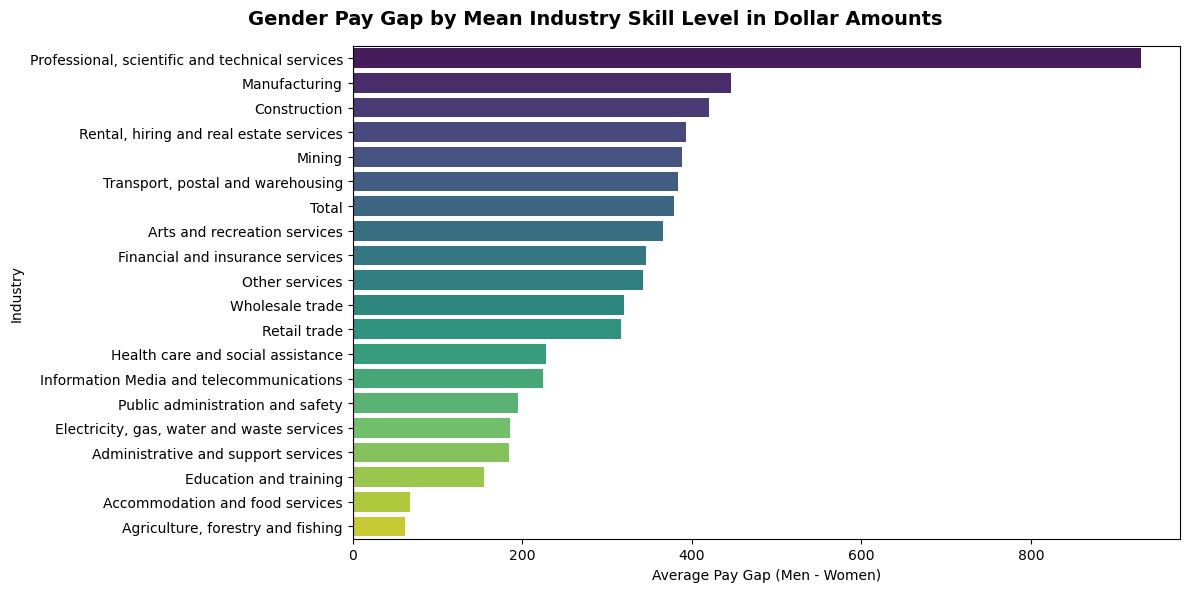

In [23]:
# --- Barplot of Skill Gender Gaps by Industry ---
plt.figure(figsize=(12,6))
sns.barplot(data=skill_results_df.sort_values("Gap", ascending=False),x="Gap", y="Industry", hue = 'Industry',palette="viridis")
plt.axvline(0, color="black", linestyle="--")
plt.suptitle("Gender Pay Gap by Mean Industry Skill Level in Dollar Amounts", fontweight='bold',fontsize=14)
plt.xlabel("Average Pay Gap (Men - Women)")
plt.ylabel("Industry")
plt.tight_layout()
plt.show()

### 7.1 Glass Ceiling Index

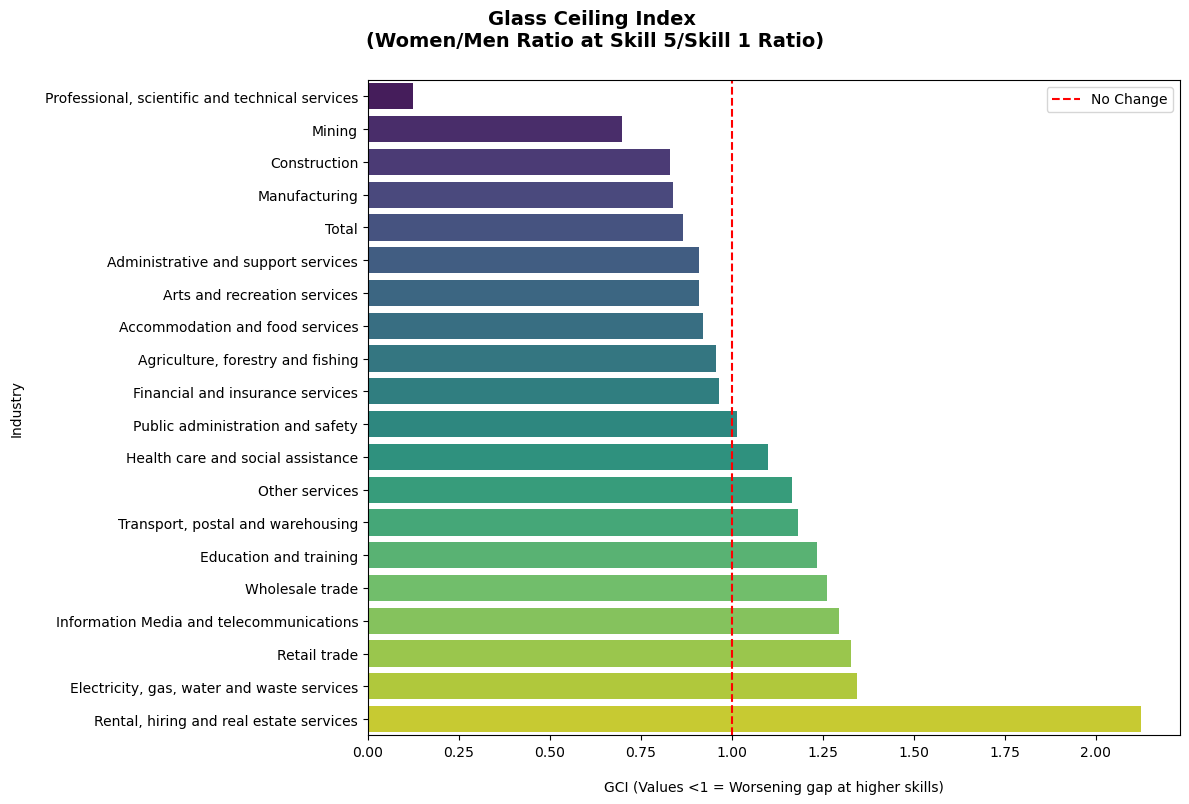

In [24]:
# --- Glass Ceiling Index (GCI) ---
gci_results = []

for industry in df_long["Industry"].unique():
    men_vals = men[men["Industry"] == industry]
    women_vals = women[women["Industry"] == industry]
    
    merged = pd.merge(
        men_vals, women_vals, on="Skill", suffixes=("_men", "_women")
    )
    
    if not merged.empty:
        # Female/Male ratio at highest (Skill 1) and lowest (Skill 5) levels
        ratio_high = merged.loc[merged["Skill"] == 1, "Pay_women"].values[0] / merged.loc[merged["Skill"] == 1, "Pay_men"].values[0] if 1 in merged["Skill"].values else None
        ratio_low = merged.loc[merged["Skill"] == 5, "Pay_women"].values[0] / merged.loc[merged["Skill"] == 5, "Pay_men"].values[0] if 5 in merged["Skill"].values else None
        
        if ratio_low is not None and ratio_high is not None:
            gci = ratio_low / ratio_high
            gci_results.append({
                "Industry": industry,
                "Ratio_Low": ratio_low,
                "Ratio_High": ratio_high,
                "GCI": gci
            })

gci_df = pd.DataFrame(gci_results)

# --- Plot GCI ---
plt.figure(figsize=(12,8))
sns.barplot(data=gci_df.sort_values("GCI"), x="GCI", y="Industry", hue='Industry',palette="viridis",legend=False)
plt.axvline(1, color="red", linestyle="--", label="No Change")
plt.suptitle("Glass Ceiling Index \n(Women/Men Ratio at Skill 5/Skill 1 Ratio)", fontweight='bold',fontsize=14,y=1)

plt.xlabel("GCI (Values <1 = Worsening gap at higher skills)",labelpad=15,fontsize =10)
plt.ylabel("Industry",labelpad=15,fontsize =10)
plt.legend()
plt.tight_layout()
plt.show()


> **Note:** Real Estate wages are largely based on commissions, so the data is not reliable in this instance.

In [25]:
#df_long = skill.melt(id_vars=['Industry','Skill'],var_name="gender", value_name="Pay")

### 7.2 Wage Gap by Skill Level — All Industries

In [26]:
test = skill_c[skill_c['Industry'] == 'Health care and social assistance']
test_c = skill_c[skill_c['Industry'] == 'Construction']
test_all = skill_c

In [27]:
test['gap'] = test['Male'] - test['Female']
test_c['gap'] = test_c['Male'] - test_c['Female']
test_all['gap'] = test_all['Male'] - test_all['Female']

/var/folders/1m/wbnyn56j6zl5cc12mcm8_5gr0000gn/T/ipykernel_46177/1946187263.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test['gap'] = test['Male'] - test['Female']
/var/folders/1m/wbnyn56j6zl5cc12mcm8_5gr0000gn/T/ipykernel_46177/1946187263.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test_c['gap'] = test_c['Male'] - test_c['Female']


/var/folders/1m/wbnyn56j6zl5cc12mcm8_5gr0000gn/T/ipykernel_46177/2093593181.py:14: UserWarning: The palette list has more values (3) than needed (2), which may not be intended.
  sns.lineplot(x='Skill', y='value', data=test2, ax=ax2, color='red', marker='o', linewidth=2,hue='variable',palette=palette)


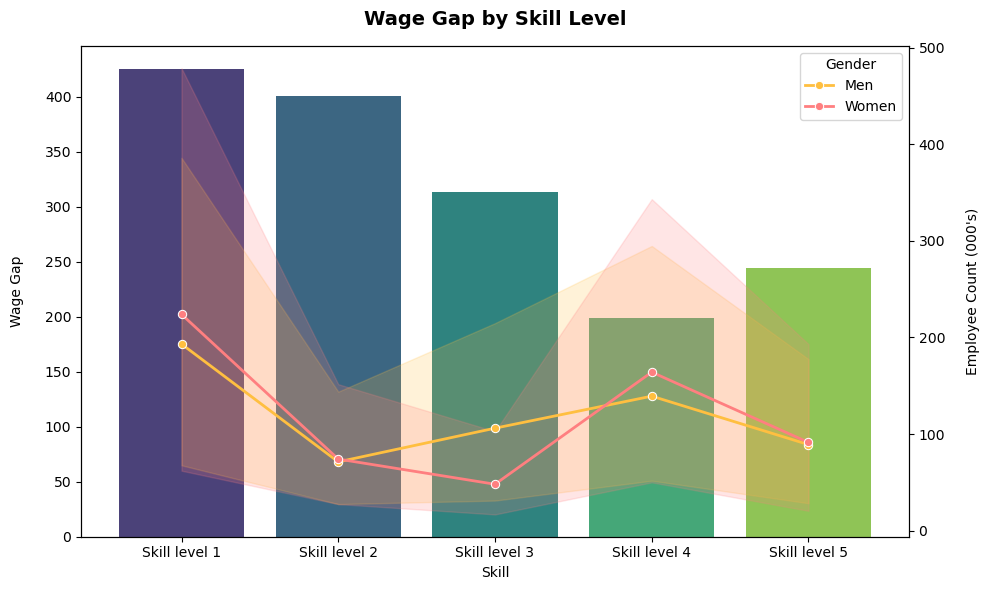

In [28]:
#--- Plot Skill Gap All --
fig, ax1 = plt.subplots(figsize=(10, 6))
sns.barplot(data=test_all,x='Skill',y='gap',ax=ax1,palette="viridis",hue='Skill',errorbar=None)
ax1.set_ylabel('Wage Gap',labelpad=15)

ax2 = ax1.twinx()

# --- Plot the line plot on ax2 ---
test2 = pd.melt(test_all,id_vars = ['Skill'],value_vars=['Male_c','Female_c'])
test2

palette = sns.color_palette("spring_r",3)

sns.lineplot(x='Skill', y='value', data=test2, ax=ax2, color='red', marker='o', linewidth=2,hue='variable',palette=palette)
handles, labels = ax2.get_legend_handles_labels()

ax2.legend(handles=handles, labels=['Men','Women'], title='Gender')
ax2.set_ylabel("Employee Count (000's)", color='black',labelpad=15)
ax2.tick_params(axis='y', labelcolor='black')


plt.title('Wage Gap by Skill Level',fontweight='bold',fontsize=14,pad=15)
fig.tight_layout()
plt.show()

### 7.3 Wage Gap by Skill Level — Health Care

/var/folders/1m/wbnyn56j6zl5cc12mcm8_5gr0000gn/T/ipykernel_46177/2142274674.py:13: UserWarning: The palette list has more values (3) than needed (2), which may not be intended.
  sns.lineplot(x='Skill', y='value', data=test2, ax=ax2, color='red', marker='o', linewidth=2,hue='variable',palette=palette)


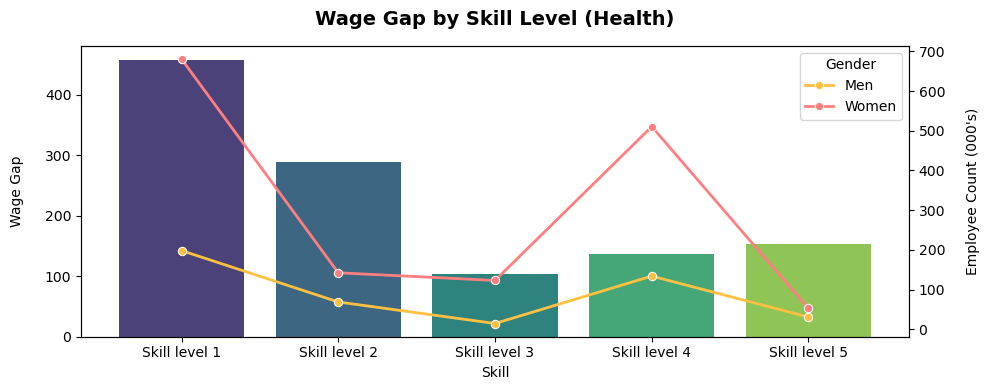

In [29]:
#--- Plot Skill gap Health---
fig, ax1 = plt.subplots(figsize=(10, 4))
sns.barplot(data=test,x='Skill',y='gap',ax=ax1,palette="viridis",hue='Skill')
ax1.set_ylabel('Wage Gap',labelpad=15)

ax2 = ax1.twinx()

# Plot the line plot on ax2
test2 = pd.melt(test,id_vars = ['Skill'],value_vars=['Male_c','Female_c'])
test2

palette = sns.color_palette("spring_r",3)
sns.lineplot(x='Skill', y='value', data=test2, ax=ax2, color='red', marker='o', linewidth=2,hue='variable',palette=palette)
handles, labels = ax2.get_legend_handles_labels()

ax2.legend(handles=handles, labels=['Men','Women'], title='Gender')
ax2.set_ylabel("Employee Count (000's)", color='black',labelpad=15)
ax2.tick_params(axis='y', labelcolor='black')


# sns.lineplot(x='Skill', y='Male_c', data=test, ax=ax2, color='red', marker='o', linewidth=2)
# ax2.set_ylabel('Line Value', color='red')
# ax2.tick_params(axis='y', labelcolor='red')

# # Set titles and layout
plt.title('Wage Gap by Skill Level (Health)',fontweight='bold',fontsize=14,pad=15)
fig.tight_layout()
plt.show()

### 7.4 Wage Gap by Skill Level — Construction

/var/folders/1m/wbnyn56j6zl5cc12mcm8_5gr0000gn/T/ipykernel_46177/2268996950.py:13: UserWarning: The palette list has more values (3) than needed (2), which may not be intended.
  sns.lineplot(x='Skill', y='value', data=test2, ax=ax2, color='red', marker='o', linewidth=2,hue='variable',palette=palette)


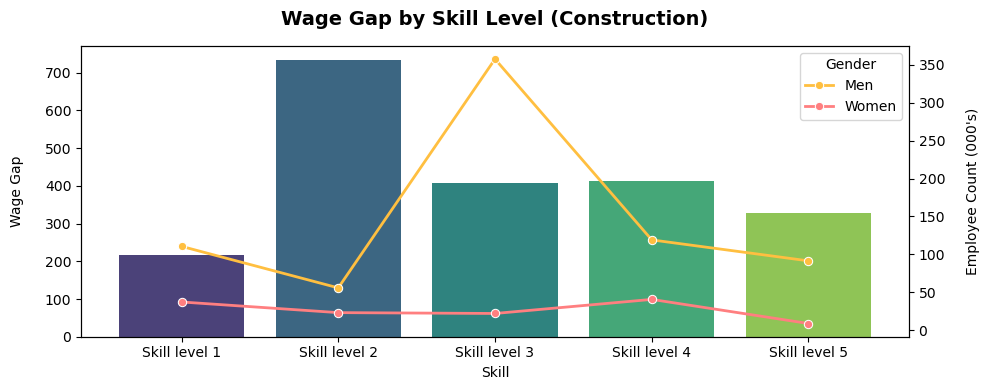

In [30]:
#--- Plot Skill gap Construction---
fig, ax1 = plt.subplots(figsize=(10, 4))
sns.barplot(data=test_c,x='Skill',y='gap',ax=ax1,palette="viridis",hue='Skill')
ax1.set_ylabel('Wage Gap',labelpad=15)

ax2 = ax1.twinx()

# Plot the line plot on ax2
test2 = pd.melt(test_c,id_vars = ['Skill'],value_vars=['Male_c','Female_c'])
test2

palette = sns.color_palette("spring_r",3)
sns.lineplot(x='Skill', y='value', data=test2, ax=ax2, color='red', marker='o', linewidth=2,hue='variable',palette=palette)
handles, labels = ax2.get_legend_handles_labels()

ax2.legend(handles=handles, labels=['Men','Women'], title='Gender')
ax2.set_ylabel("Employee Count (000's)", color='black',labelpad=15)
ax2.tick_params(axis='y', labelcolor='black')


# sns.lineplot(x='Skill', y='Male_c', data=test, ax=ax2, color='red', marker='o', linewidth=2)
# ax2.set_ylabel('Line Value', color='red')
# ax2.tick_params(axis='y', labelcolor='red')

# # Set titles and layout
plt.title('Wage Gap by Skill Level (Construction)',fontweight='bold',fontsize=14,pad=15)
fig.tight_layout()
plt.show()

---

## 8. CEO Gender Split by Industry

In [31]:
df2_ceo = df2[df2['occupation'].isin(['CEOs'])]
df2_ceo = df2_ceo[df2_ceo['corporate_group_name'] != 'Specsavers Pty. Ltd.'] # 434.0 men 428.0 women CEO's

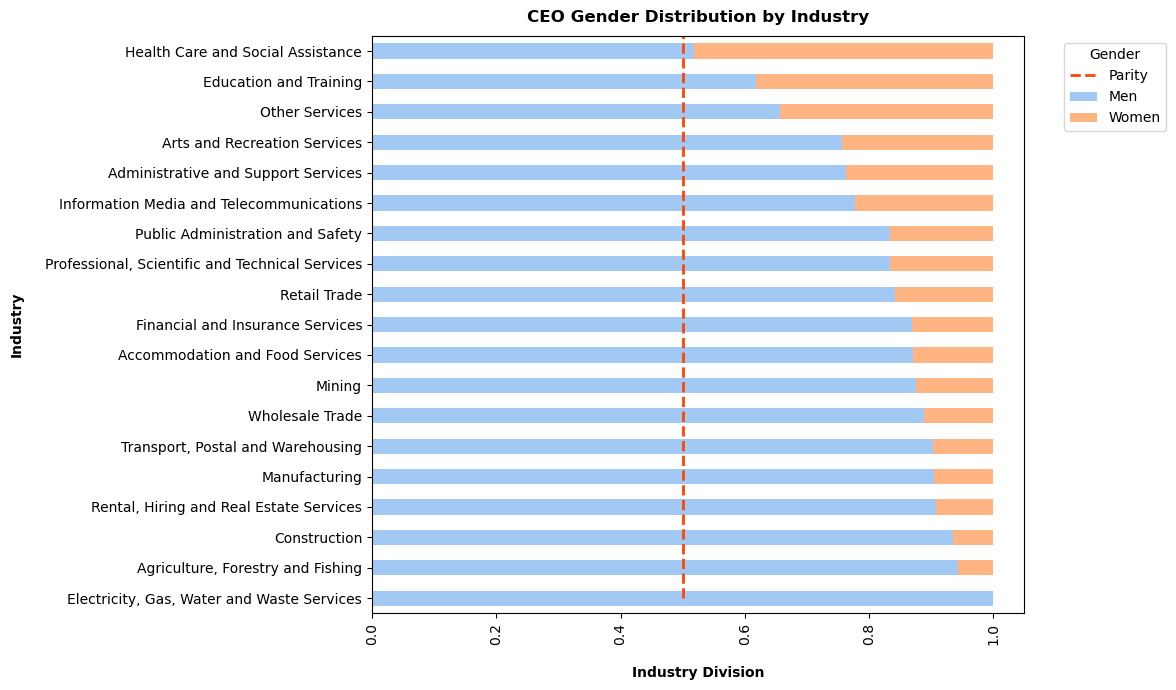

In [32]:
# --- CEO gender split by industry ---
industry_ct = pd.crosstab(
    df2_ceo['anzsic_division'],
    df2_ceo['gender'],
    values=df2_ceo['n_employees'],
    aggfunc='sum'
).fillna(0)

industry_ct_norm = industry_ct.div(industry_ct.sum(axis=1), axis=0).sort_values(by='Men',ascending=False)
industry_ct_norm.plot(kind="barh", stacked=True, figsize=(12,7))
plt.title("CEO Gender Distribution by Industry",fontweight='bold',pad=10)
plt.ylabel("Industry",labelpad=15,fontweight='bold')
plt.xlabel("Industry Division",labelpad=15,fontweight='bold')
plt.xticks(rotation=90)
plt.vlines(x=0.5, ymin=0, ymax=19, colors='orangered', linestyles='dashed', label='Parity',linewidth=2)
plt.legend(title="Gender", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

---

## 9. Workplace Equality Questionnaire

WGEA conducts its research by sending out a questionnaire to all employers with 100 or more employees. The topics covered by the questionnaire include: Harm Protection, Action on Gender Equality, Flexible work, Workplace overview and Employee support. Based on the results of this questionnaire, we can see how many companies have taken steps to address the issue of unequal pay.

### 9.1 Survey Questions

- **Q2.1:** Do you have formal policies and/or formal strategies on equal remuneration (pay equity and the gender pay gap) between women and men?
- **Q2.2:** Have you analysed your payroll to determine if there are any remuneration gaps between women and men (e.g. conducted a gender pay gap analysis)?
- **Q2.2c:** Did you take any actions as a result of your gender remuneration gap analysis?

**Answer Key:**  
**Y** = Yes | **N** = No | **Dev** = In Development | **Clik** = Corrected instances of unequal pay | **TOrg** = Set targets to reduce any gender pay gaps

### 9.2 Load Questionnaire Data

In [33]:
# --- Load Data ---
dfq = pd.read_csv('Data/wgea_public_dataset_2024/wgea_questionnaire_action_on_gender_equality_2024.csv')
# corporate_group_name includes parent companies
# employer_name is direct employer

df5 = pd.read_csv('Data/wgea_public_dataset_2024/wgea_workforce_composition_2024.csv')
df5['is_relevant_employer'] = df5['is_relevant_employer'] != 'False' # removes subsidaries

quest = dfq[dfq['subsection'] == 'Gender Pay Gap']
quest = dfq[dfq['corporate_group_name'] != 'Specsavers Pty. Ltd.'] # 434.0 men 428.0 women CEO's

In [35]:
# --- Build data ---
healthq = quest.query("anzsic_division == 'Health Care and Social Assistance'")

all_ind = quest[['corporate_group_name','question_index']]
all_ind2 = quest[['anzsic_division','corporate_group_name','question_index']]
healthq = healthq[['corporate_group_name','question_index']]

healthq = healthq.drop_duplicates()
all_ind = all_ind.drop_duplicates()

ceo = df5[['corporate_group_name','occupation','gender','n_employees']]
ceo = ceo[ceo['occupation'] == 'CEOs']
ceo = ceo.groupby(['corporate_group_name','gender'])['n_employees'].sum().reset_index()

merged_health = pd.merge(ceo, healthq, on='corporate_group_name', how='inner')
merged_all = pd.merge(ceo, all_ind, on='corporate_group_name', how='inner')
merged_ind = pd.merge(ceo, all_ind2, on='corporate_group_name', how='inner')
merged_ind = merged_ind.drop_duplicates()

ceo_list = merged_all.pivot_table(index='corporate_group_name',columns='gender',values='n_employees').fillna(0).reset_index()
ceo_list['diff'] = ceo_list['Men'] - ceo_list['Women']

# Add label based on difference
ceo_list["ratio"] = ceo_list["diff"].apply(
    lambda x: "Men" if x > 0 else "Women" if x < 0 else "Equal")

ceo_dict = dict(zip(ceo_list['corporate_group_name'], ceo_list['ratio']))

merged_ind['ratio'] = merged_ind['corporate_group_name'].map(ceo_dict)

In [36]:
ceo_list


gender,corporate_group_name,Men,Women,diff,ratio
0,1-STOP CONNECTIONS PTY LIMITED,0.0,1.0,-1.0,Women
1,1884 Pty Ltd,1.0,0.0,1.0,Men
2,233 VICTORIA SQUARE HOTEL PTY LTD,1.0,0.0,1.0,Men
3,29Metals Limited,1.0,0.0,1.0,Men
4,2Xu Pty Ltd,1.0,0.0,1.0,Men
...,...,...,...,...,...
4580,Zircodata Holdings Pty Ltd,0.0,1.0,-1.0,Women
4581,Zurich Financial Services Australia Limited,1.0,0.0,1.0,Men
4582,dvconnect Limited,0.0,1.0,-1.0,Women
4583,myHomecare Pty Ltd,1.0,0.0,1.0,Men


### 9.3 Question Index Definitions

In [37]:
# --- Question Index ---

# 2.1 Do you have formal policies and/or formal strategies on equal remuneration
policy = ['GPG.Rem.N','GPG.Rem.N.Dev','GPG.Rem.Y']
# 2.2  Have you analysed your payroll to determine if there are any remuneration gaps between women and men (e.g. conducted a gender pay gap analysis)?
analyse = ['EAct.Anl.N','EAct.Anl.Y','EAct.Anl.N.Dev']
# 2.2c Did you take any actions as a result of your gender remuneration gap analysis?
action = ['EAct.Act.N','EAct.Act.N.Dev','EAct.Act.Y','EAct.Act.Y.Clik','EAct.Act.Y.TOrg']

In [38]:
# --- Get answers based on question and industry ---
def get_answer(answer,industry):

    """
    Get answers from the questionnaire based on the question and industry.

    Parameters:
    - answer: mask using list of question_index values to filter results
    - industry: dataset
    
    """
    
    corp = []
    question = []
    ratio = []

    # Filter out questions
    for each in answer:
        results = industry[industry['question_index'] == each]

        # Get company name and add to list
        corpo = results['corporate_group_name']
        for item in corpo:
            s = pd.Series(item)
            corp.append(s)

        # Get answers and add to list
        questions = results['question_index']
        for item in questions:
            s = pd.Series(item)
            question.append(s)

    # Join lists
    corps = pd.concat(corp)
    questions = pd.concat(question)

    # Create dataframe from lists
    df = pd.concat([corps,questions],axis=1)
    df.columns = ['corporate_group_name','answer']

    # Keep last part of question_index to denote the answer given
    df['answer'] = df['answer'].str.rsplit('.', n=1).str[1]

    # Map CEO gender ratio from dictionary
    df['ratio'] = df['corporate_group_name'].map(ceo_dict)

    return df


### 9.4 Overall Response Distribution

This is how the employers answered across the whole dataset.

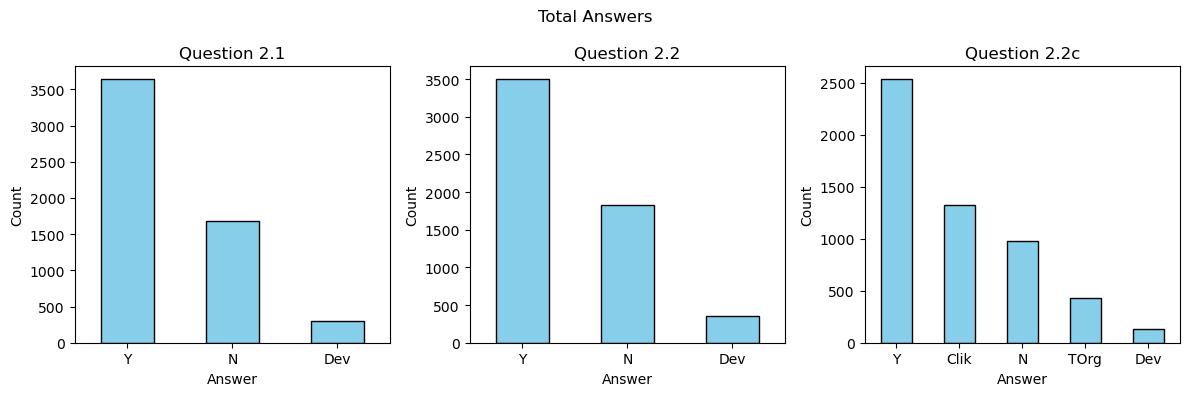

In [42]:
# Count frequencies of each answer type

health_p = get_answer(policy,healthq)
health_an = get_answer(analyse,healthq)
health_ac = get_answer(action,healthq)

merged_p = get_answer(policy,merged_ind)
merged_an = get_answer(analyse,merged_ind)
merged_ac = get_answer(action,merged_ind)

pol = merged_p["answer"].value_counts()
an = merged_an["answer"].value_counts()
ac = merged_ac["answer"].value_counts()

plt.subplot(1, 3, 1)
pol.plot(kind="bar", color="skyblue", edgecolor="black",figsize=(12,4),rot=0)
plt.title("Question 2.1")
plt.xlabel("Answer")
plt.ylabel("Count")

plt.subplot(1, 3, 2)
an.plot(kind="bar", color="skyblue", edgecolor="black",rot=0)
plt.title("Question 2.2")
plt.xlabel("Answer")
plt.ylabel("Count")

plt.subplot(1, 3, 3)
ac.plot(kind="bar", color="skyblue", edgecolor="black",rot=0)
plt.title("Question 2.2c")
plt.xlabel("Answer")
plt.ylabel("Count")

plt.suptitle("Total Answers")
plt.tight_layout()

plt.show()

### 9.5 Responses by CEO Gender Ratio

This is how the answers stacked up based on gender ratio of the company CEOs.

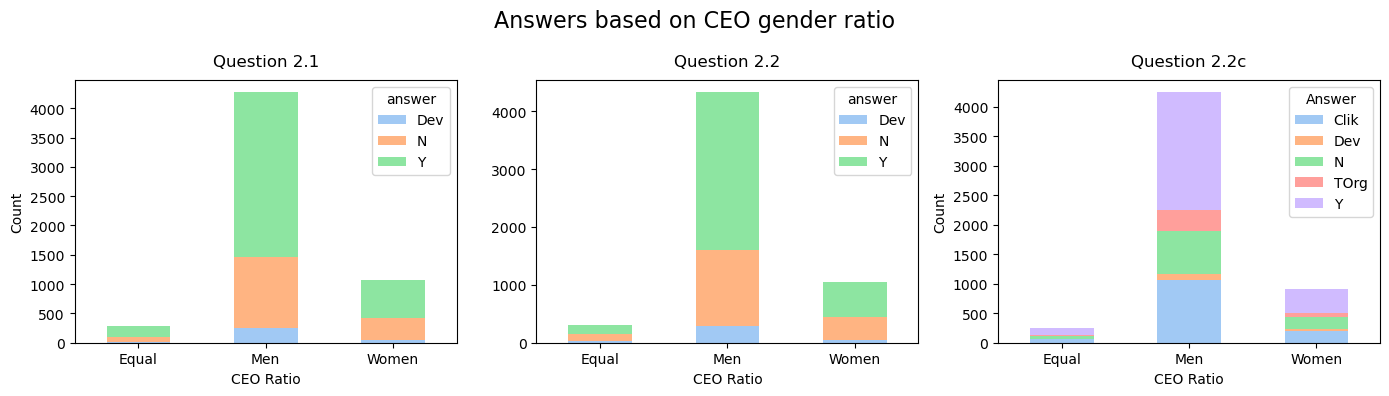

In [40]:
# Crosstab for stacked bar
cross_p = pd.crosstab(merged_p["ratio"], merged_p["answer"])
cross_an = pd.crosstab(merged_an["ratio"], merged_an["answer"])
cross_ac = pd.crosstab(merged_ac["ratio"], merged_ac["answer"])

fig, axs = plt.subplots(1,3,figsize=(14,4))

fig.suptitle('Answers based on CEO gender ratio', fontsize=16)

cross_p.plot(kind="bar", stacked=True, ax=axs[0],rot=0)
axs[0].set_title("Question 2.1",pad=10)
axs[0].set_xlabel("CEO Ratio")
axs[0].set_ylabel("Count")

cross_an.plot(kind="bar", stacked=True,ax=axs[1],rot=0)
axs[1].set_title("Question 2.2",pad=10)
axs[1].set_xlabel("CEO Ratio")
plt.ylabel("Count")

cross_ac.plot(kind="bar", stacked=True,ax=axs[2],rot=0)
axs[2].set_title("Question 2.2c",pad=10)
axs[2].set_xlabel("CEO Ratio")
plt.ylabel("Count")
plt.legend(title="Answer")

plt.tight_layout()
plt.show()

---

## 10. Hypothesis Testing

As seen above, the Health Care industry has the largest proportion of women in the workforce, the largest pay gap in the industry, but is the closest to parity in terms of CEO gender equality.

**Hypothesis:** CEO gender determines action on gender pay equality

The heatmaps below show the frequency of answers based on CEO gender. Overwhelmingly, majority female CEO companies responded in the positive.

### 10.1 Build Contingency Tables

In [43]:
# --- build contingency tables ---
all_p = get_answer(policy,merged_ind)
all_an = get_answer(analyse,merged_ind)
all_ac = get_answer(action,merged_ind)

h_pol = pd.crosstab(health_p['answer'], health_p['ratio'])
h_an = pd.crosstab(health_an['answer'], health_an['ratio'])
h_ac = pd.crosstab(health_ac['answer'], health_ac['ratio'])

all_pol = pd.crosstab(all_p['answer'], all_p['ratio'])
all_an = pd.crosstab(all_an['answer'], all_an['ratio'])
all_ac = pd.crosstab(all_ac['answer'], all_ac['ratio'])

### 10.2 Overall Heatmaps — CEO Ratio vs Answers

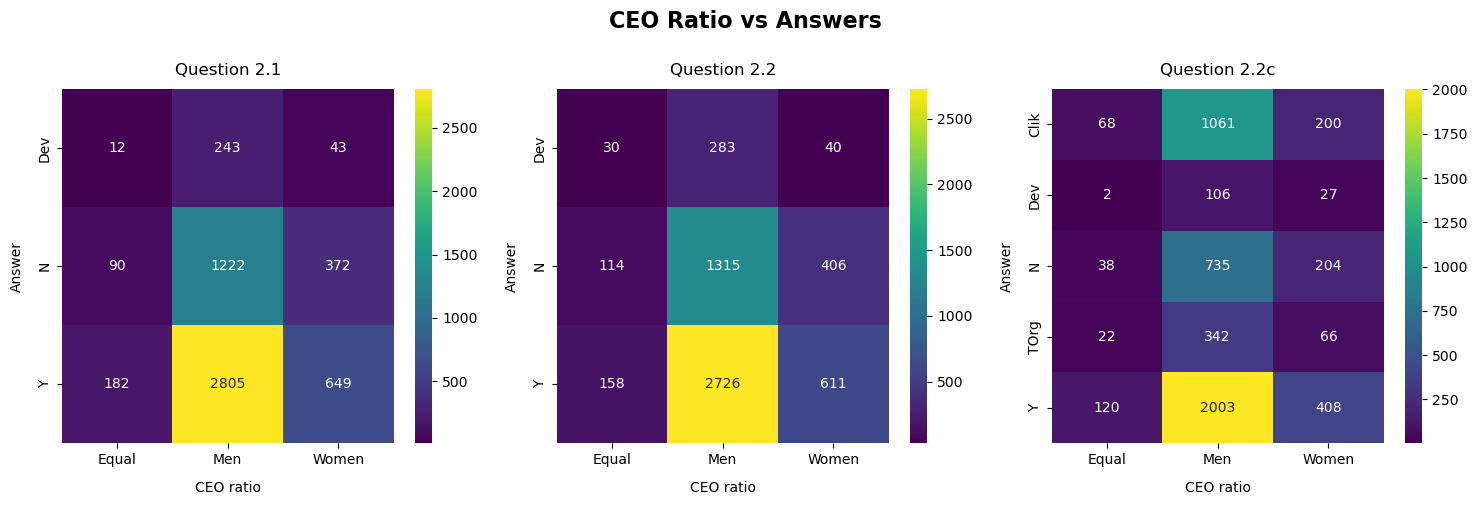

In [44]:
# --- Overall Heatmap ---
fig, axs = plt.subplots(1, 3, figsize=(15, 5))

fig.suptitle('CEO Ratio vs Answers', fontsize=16,fontweight='bold',y=1)

sns.heatmap(all_pol, annot=True, cmap='viridis', fmt='d',ax=axs[0])
axs[0].set_title('Question 2.1',pad=10)
axs[0].set_xlabel('CEO ratio',labelpad=10)
axs[0].set_ylabel('Answer',labelpad=10)

sns.heatmap(all_an, annot=True, cmap='viridis', fmt='d',ax=axs[1])
axs[1].set_title('Question 2.2',pad=10)
axs[1].set_xlabel('CEO ratio',labelpad=10)
axs[1].set_ylabel('Answer',labelpad=10)

sns.heatmap(all_ac, annot=True, cmap='viridis', fmt='d',ax=axs[2])
axs[2].set_title('Question 2.2c',pad=10)
axs[2].set_xlabel('CEO ratio',labelpad=10)
axs[2].set_ylabel('Answer',labelpad=10)

plt.tight_layout()
plt.show()

### 10.3 Chi-Square Test Function

In [45]:
# --- Subset vs Overall function ---

def subset_vs_overall_test(df, subset_filter, category_col, weight_col="count"):
    """
    Compare subset distribution of a categorical variable to the whole dataset.

    Parameters:
    - df: pandas DataFrame
    - subset_filter: boolean mask (e.g. df["anzsic_division"]=="Mining")
    - category_col: column with categories (e.g. "ratio" or "answer")
    - weight_col: column with counts (default="count")
    """

    # Overall distribution (weighted counts)
    overall = df.groupby(category_col)[weight_col].sum()
    overall_prop = overall / overall.sum()

    # Subset distribution
    subset = df.loc[subset_filter].groupby(category_col)[weight_col].sum()

    # Align categories (fill missing with 0)
    subset = subset.reindex(overall.index, fill_value=0)

    # Expected counts = overall proportions * subset size
    expected = overall_prop * subset.sum()

    # Run chi-square goodness-of-fit
    chi2, p = chisquare(f_obs=subset, f_exp=expected)

    print(f"\n--- Subset vs Overall Test ({category_col}) ---")
    print("Subset size:", subset.sum())
    print("Chi-square statistic:", round(chi2, 3))
    print("p-value:", f"{p:.2f}")
    if p < 0.05:
        print("We reject our null hypothesis")
    else:
        print("We fail to reject our null hypothesis")
    print('\n','-'*50)

    return subset, expected


### 10.4 Prepare Data by Question

In [46]:
# --- heatmap policy ---
merged_ind_p = merged_ind[merged_ind['question_index'].isin(policy)]
merged_ind_p['answer'] = merged_ind_p['question_index'].str.rsplit('.', n=1).str[1]
merged_ind_p.iloc[:,[3,4,5]]
grouped_p = merged_ind_p.groupby(['anzsic_division','answer'])['ratio'].value_counts().reset_index()

/var/folders/1m/wbnyn56j6zl5cc12mcm8_5gr0000gn/T/ipykernel_46177/1531817904.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  merged_ind_p['answer'] = merged_ind_p['question_index'].str.rsplit('.', n=1).str[1]


In [47]:
# --- heatmap analyse ---
merged_ind_an = merged_ind[merged_ind['question_index'].isin(analyse)]
merged_ind_an['answer'] = merged_ind_an['question_index'].str.rsplit('.', n=1).str[1]
merged_ind_an.iloc[:,[3,4,5]]
grouped_an = merged_ind_an.groupby(['anzsic_division','answer'])['ratio'].value_counts().reset_index()

/var/folders/1m/wbnyn56j6zl5cc12mcm8_5gr0000gn/T/ipykernel_46177/2661048567.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  merged_ind_an['answer'] = merged_ind_an['question_index'].str.rsplit('.', n=1).str[1]


In [48]:
#--- heatmap actions ---
merged_ind_ac = merged_ind[merged_ind['question_index'].isin(action)]
merged_ind_ac['answer'] = merged_ind_ac['question_index'].str.rsplit('.', n=1).str[1]
merged_ind_ac.iloc[:,[3,4,5]]
grouped_ac = merged_ind_ac.groupby(['anzsic_division','answer'])['ratio'].value_counts().reset_index()


/var/folders/1m/wbnyn56j6zl5cc12mcm8_5gr0000gn/T/ipykernel_46177/557677306.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  merged_ind_ac['answer'] = merged_ind_ac['question_index'].str.rsplit('.', n=1).str[1]


### 10.5 Health Care vs Overall — Chi-Square Tests

**CEO Ratio Distribution:**


--- Subset vs Overall Test (ratio) ---
Subset size: 871
Chi-square statistic: 353.248
p-value: 0.00
We reject our null hypothesis

 --------------------------------------------------


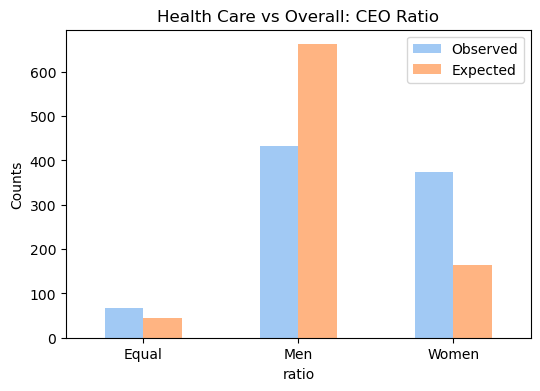

In [49]:
# --- Compare industry ratio distribution vs overall ---
subset, expected = subset_vs_overall_test(
    grouped_p,
    grouped_p["anzsic_division"]=="Health Care and Social Assistance",
    category_col="ratio",
    weight_col="count"
)

df_plot = pd.DataFrame({"Observed": subset, "Expected": expected})
df_plot.plot(kind="bar", figsize=(6,4),rot=0)
plt.title(f"Health Care vs Overall: CEO Ratio")
plt.ylabel("Counts")
plt.show()

**Question 2.1 — Equal Remuneration Policy:**


--- Subset vs Overall Test (answer) ---
Subset size: 871
Chi-square statistic: 43.396
p-value: 0.00
We reject our null hypothesis

 --------------------------------------------------


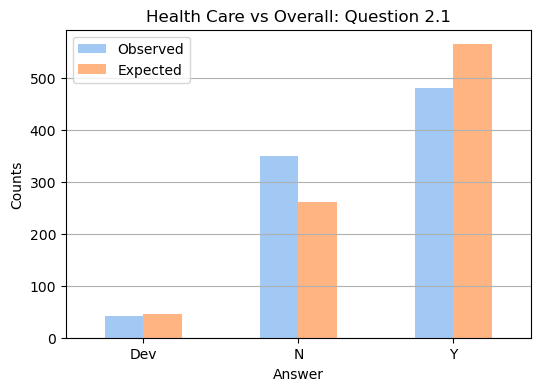

In [50]:
# --- Compare industry policy answer distribution vs overall ---
subset, expected = subset_vs_overall_test(
    grouped_p,
    grouped_p["anzsic_division"] == "Health Care and Social Assistance",
    category_col="answer",
    weight_col="count"
)
palet = sns.color_palette("viridis_r")
df_plot = pd.DataFrame({"Observed": subset, "Expected": expected})
df_plot.plot(kind="bar", figsize=(6,4),rot=0)
plt.title(f"Health Care vs Overall: Question 2.1")
plt.ylabel("Counts")
plt.grid(axis='y')
plt.xlabel("Answer")
plt.show()

**Question 2.2 — Pay Gap Analysis:**


--- Subset vs Overall Test (answer) ---
Subset size: 885
Chi-square statistic: 121.287
p-value: 0.00
We reject our null hypothesis

 --------------------------------------------------


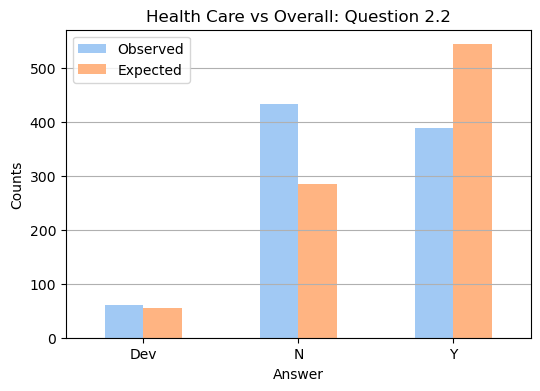

In [51]:
# --- Compare industry analysis answer distribution vs overall ---
subset, expected = subset_vs_overall_test(
    grouped_an,
    grouped_an["anzsic_division"] == "Health Care and Social Assistance",
    category_col="answer",
    weight_col="count"
)
palet = sns.color_palette("viridis_r")
df_plot = pd.DataFrame({"Observed": subset, "Expected": expected})
df_plot.plot(kind="bar", figsize=(6,4),rot=0)
plt.title(f"Health Care vs Overall: Question 2.2")
plt.ylabel("Counts")
plt.grid(axis='y')
plt.xlabel("Answer")
plt.show()

**Question 2.2c — Actions Taken:**


--- Subset vs Overall Test (answer) ---
Subset size: 507
Chi-square statistic: 105.611
p-value: 0.00
We reject our null hypothesis

 --------------------------------------------------


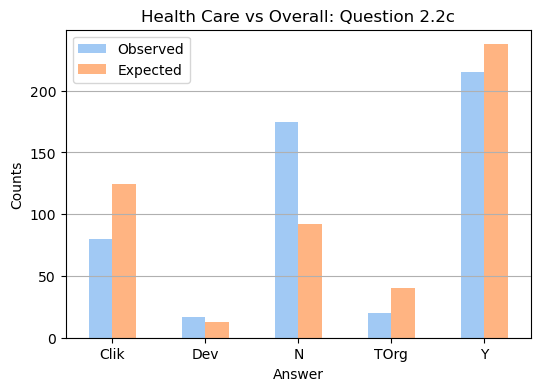

In [52]:
# --- Compare industry policy action distribution vs overall ---
subset, expected = subset_vs_overall_test(
    grouped_ac,
    grouped_ac["anzsic_division"] == "Health Care and Social Assistance",
    category_col="answer",
    weight_col="count"
)
palet = sns.color_palette("viridis_r")
df_plot = pd.DataFrame({"Observed": subset, "Expected": expected})
df_plot.plot(kind="bar", figsize=(6,4),rot=0)
plt.title(f"Health Care vs Overall: Question 2.2c")
plt.ylabel("Counts")
plt.grid(axis='y')
plt.xlabel("Answer")
plt.show()

### 10.6 Heatmaps — Answers by Industry & CEO Gender

**Question 2.1:**

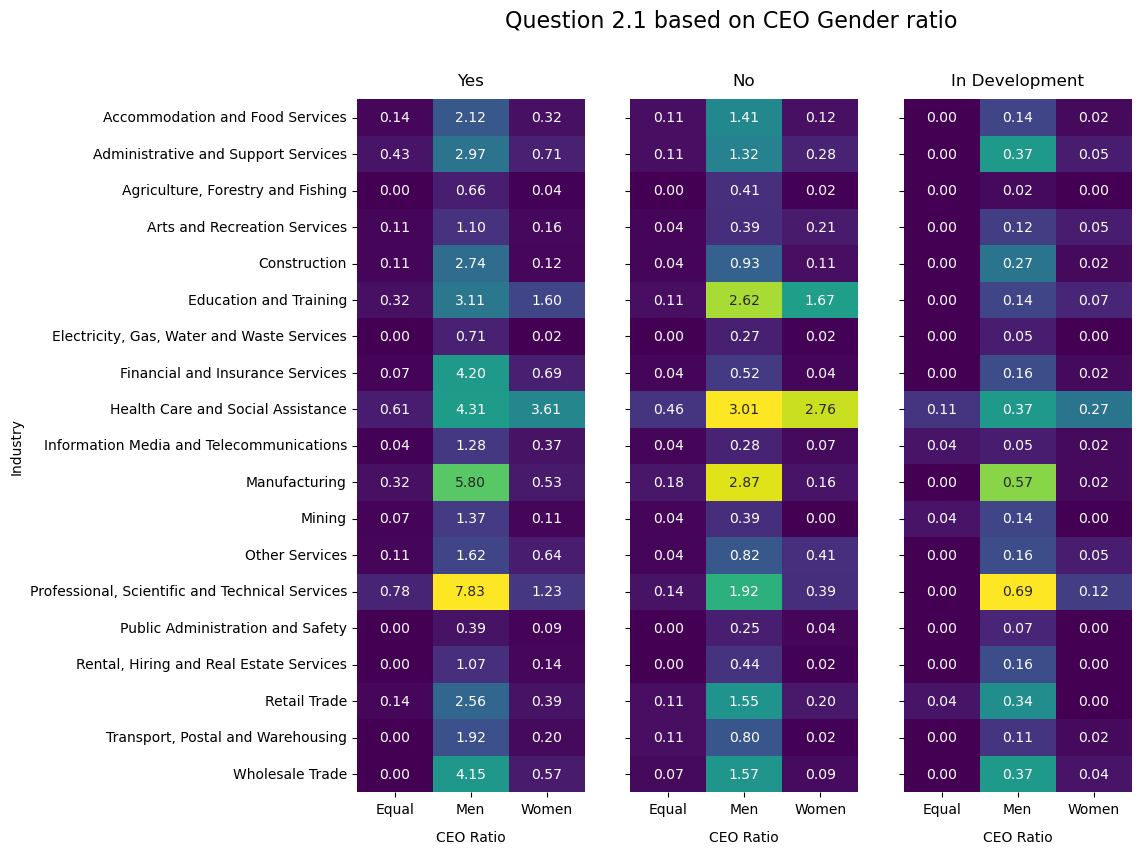

In [53]:
# --- Heatmap of answers by CEO gender ---

grouped_y = grouped_p[grouped_p['answer'] == 'Y']
grouped_n = grouped_p[grouped_p['answer'] == 'N']
grouped_d = grouped_p[grouped_p['answer'] == 'Dev']

group_p = grouped_p.pivot_table(index='anzsic_division',columns=['ratio'],values='count',aggfunc='sum').fillna(0)
group_y = grouped_y.pivot_table(index='anzsic_division',columns=['ratio'],values='count',aggfunc='sum').fillna(0)
group_n = grouped_n.pivot_table(index='anzsic_division',columns=['ratio'],values='count',aggfunc='sum').fillna(0)
group_d = grouped_d.pivot_table(index='anzsic_division',columns=['ratio'],values='count',aggfunc='sum').fillna(0)
fig, axs = plt.subplots(1,3,figsize=(10,9))

fig.suptitle('Question 2.1 based on CEO Gender ratio', fontsize=16)

sns.heatmap((group_y / group_p.values.sum()) * 100, fmt=".2f",cmap="viridis",ax=axs[0],annot=True,cbar=False)
axs[0].set_title("Yes",pad=10)
axs[0].set(ylabel='Industry')
axs[0].set_xlabel("CEO Ratio",labelpad=10)


sns.heatmap((group_n / group_p.values.sum()) * 100, fmt=".2f", cmap="viridis",ax=axs[1],annot=True,cbar=False)
axs[1].set(ylabel='')
axs[1].set_yticklabels('')
axs[1].set_title("No",pad=10)
axs[1].set_xlabel("CEO Ratio",labelpad=10)


sns.heatmap((group_d / group_p.values.sum()) * 100, fmt=".2f", cmap="viridis",ax=axs[2],annot=True,cbar=False)
axs[2].set(ylabel='')
axs[2].set_yticklabels('')
axs[2].set_title("In Development",pad=10)
axs[2].set_xlabel("CEO Ratio",labelpad=10)
# plt.tight_layout()

plt.show()


**Question 2.2:**

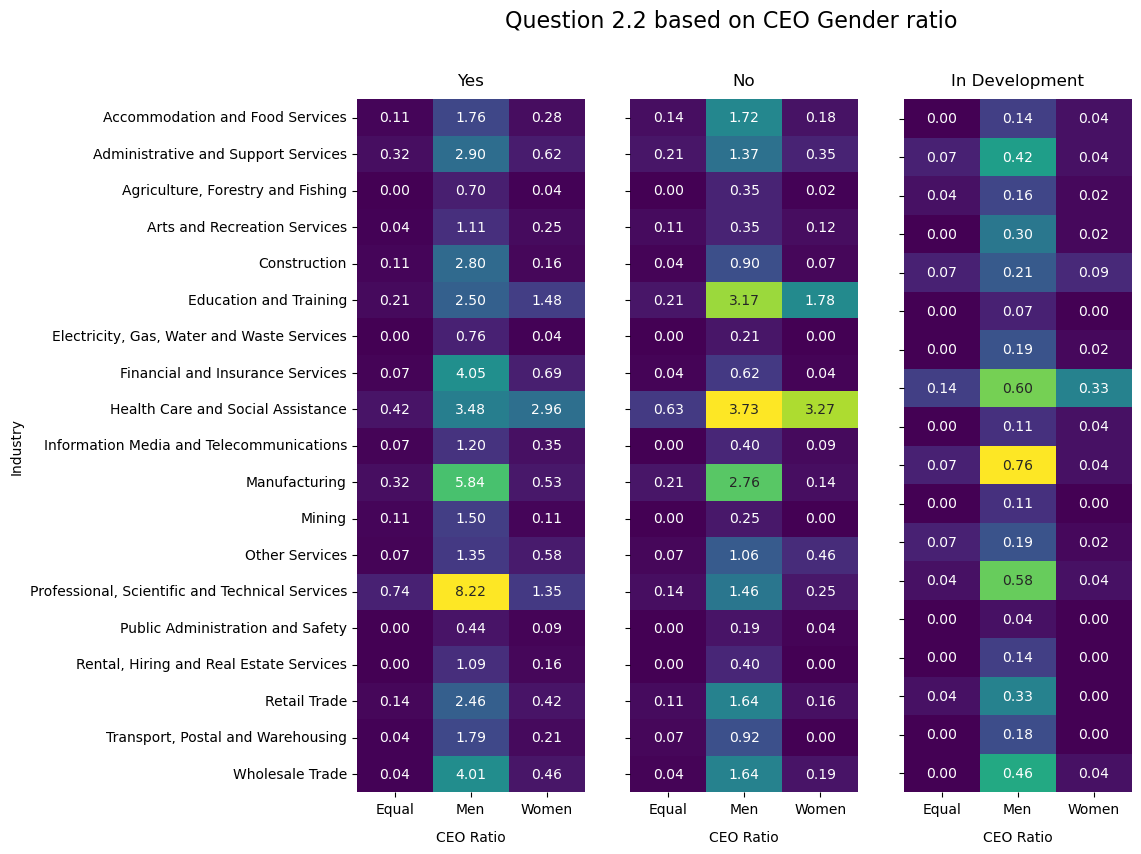

In [54]:
# --- Heatmap of analysis answers by CEO gender ---
grouped_y = grouped_an[grouped_an['answer'] == 'Y']
grouped_n = grouped_an[grouped_an['answer'] == 'N']
grouped_d = grouped_an[grouped_an['answer'] == 'Dev']

group_an = grouped_an.pivot_table(index='anzsic_division',columns=['ratio'],values='count',aggfunc='sum').fillna(0)
group_y = grouped_y.pivot_table(index='anzsic_division',columns=['ratio'],values='count',aggfunc='sum').fillna(0)
group_n = grouped_n.pivot_table(index='anzsic_division',columns=['ratio'],values='count',aggfunc='sum').fillna(0)
group_d = grouped_d.pivot_table(index='anzsic_division',columns=['ratio'],values='count',aggfunc='sum').fillna(0)

fig, axs = plt.subplots(1,3,figsize=(10,9))

fig.suptitle('Question 2.2 based on CEO Gender ratio', fontsize=16)

sns.heatmap((group_y / group_an.values.sum()) * 100, fmt=".2f",cmap="viridis",ax=axs[0],annot=True,cbar=False)
axs[0].set_title("Yes",pad=10)
axs[0].set(ylabel='Industry')
axs[0].set_xlabel("CEO Ratio",labelpad=10)


sns.heatmap((group_n / group_an.values.sum()) * 100, fmt=".2f", cmap="viridis",ax=axs[1],annot=True,cbar=False)
axs[1].set(ylabel='')
axs[1].set_yticklabels('')
axs[1].set_title("No",pad=10)
axs[1].set_xlabel("CEO Ratio",labelpad=10)


sns.heatmap((group_d / group_an.values.sum()) * 100, fmt=".2f", cmap="viridis",ax=axs[2],annot=True,cbar=False)
axs[2].set(ylabel='')
axs[2].set_yticklabels('')
axs[2].set_title("In Development",pad=10)
axs[2].set_xlabel("CEO Ratio",labelpad=10)
# plt.tight_layout()

plt.show()


**Question 2.2c:**

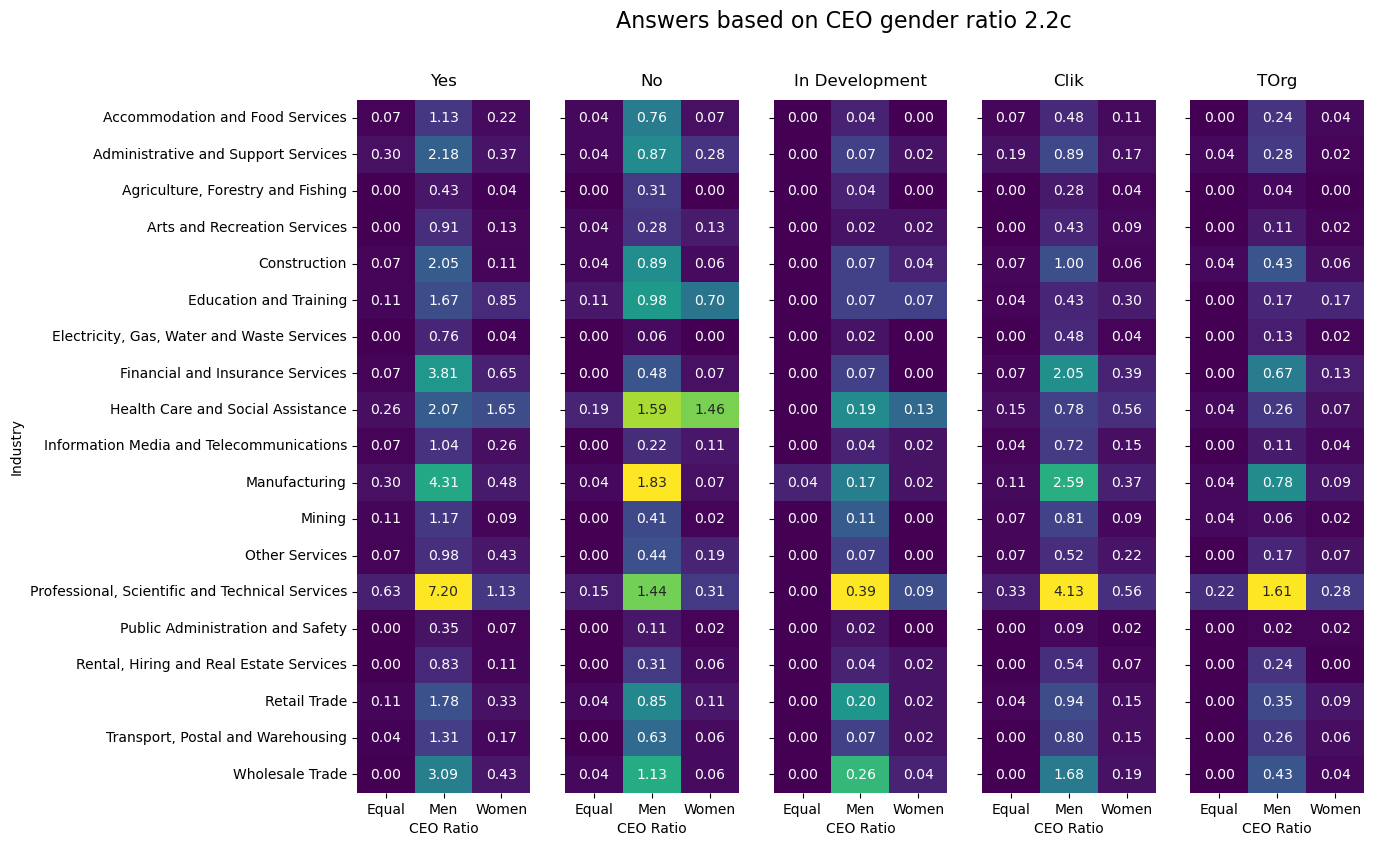

In [55]:
# --- Heatmap of action by CEO gender ---

grouped_y = grouped_ac[grouped_ac['answer'] == 'Y']
grouped_n = grouped_ac[grouped_ac['answer'] == 'N']
grouped_d = grouped_ac[grouped_ac['answer'] == 'Dev']
grouped_c = grouped_ac[grouped_ac['answer'] == 'Clik']
grouped_t = grouped_ac[grouped_ac['answer'] == 'TOrg']

group_ac = grouped_ac.pivot_table(index='anzsic_division',columns=['ratio'],values='count',aggfunc='sum').fillna(0)
group_y = grouped_y.pivot_table(index='anzsic_division',columns=['ratio'],values='count',aggfunc='sum').fillna(0)
group_n = grouped_n.pivot_table(index='anzsic_division',columns=['ratio'],values='count',aggfunc='sum').fillna(0)
group_d = grouped_d.pivot_table(index='anzsic_division',columns=['ratio'],values='count',aggfunc='sum').fillna(0)
group_c = grouped_c.pivot_table(index='anzsic_division',columns=['ratio'],values='count',aggfunc='sum').fillna(0)
group_t = grouped_t.pivot_table(index='anzsic_division',columns=['ratio'],values='count',aggfunc='sum').fillna(0)

fig, axs = plt.subplots(1,5,figsize=(13,9))

fig.suptitle('Answers based on CEO gender ratio 2.2c', fontsize=16)

sns.heatmap((group_y / group_ac.values.sum()) * 100, fmt=".2f", cmap="viridis",ax=axs[0],annot=True,cbar=False)
# plt.title("Corporate Group Ratios Yes")
axs[0].set_title("Yes",pad=10)
axs[0].set(ylabel='Industry')
axs[0].set_xlabel("CEO Ratio")

# plt.figure(figsize=(4,6))
sns.heatmap((group_n / group_ac.values.sum()) * 100, fmt=".2f", cmap="viridis",ax=axs[1],annot=True,cbar=False)
axs[1].set(ylabel='')
axs[1].set_yticklabels('')
axs[1].set_title("No",pad=10)
axs[1].set_xlabel("CEO Ratio")

# plt.figure(figsize=(4,6))
sns.heatmap((group_d / group_ac.values.sum()) * 100, fmt=".2f", cmap="viridis",ax=axs[2],annot=True,cbar=False)
axs[2].set(ylabel='')
axs[2].set_yticklabels('')
axs[2].set_title("In Development",pad=10)
axs[2].set_xlabel("CEO Ratio")

sns.heatmap((group_c / group_ac.values.sum()) * 100, fmt=".2f", cmap="viridis",ax=axs[3],annot=True,cbar=False)
axs[3].set(ylabel='')
axs[3].set_yticklabels('')
axs[3].set_title("Clik",pad=10)
axs[3].set_xlabel("CEO Ratio")

sns.heatmap((group_t / group_ac.values.sum()) * 100, fmt=".2f", cmap="viridis",ax=axs[4],annot=True,cbar=False)
axs[4].set(ylabel='')
axs[4].set_yticklabels('')
axs[4].set_title("TOrg",pad=10)
axs[4].set_xlabel("CEO Ratio")
# plt.tight_layout()

plt.show()
